# Logistic Regression Model

In [ ]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
from scipy.stats import gamma
from sklearn.model_selection import train_test_split
from sklearn.metrics import classification_report, confusion_matrix
from sklearn.linear_model import LogisticRegression
from sklearn.metrics import accuracy_score

### Data Preparation ###
expeditions = "data/expeditions.csv"

# Load the CSV file
df_raw = pd.read_csv(expeditions)

# Filter Data: Consider expeditions where the maximum elevation reached is above 7000 meters 
# (likely to focus on higher-risk expeditions)
df = df_raw[df_raw['max_elev_reached'] > 7000]

print(f"shape of raw: {df_raw.shape} , shape after elevation restriction: {df.shape}")

# List of some of the features from the dataset to be measured
features = ['peak_name', 'year', 'season', 'leaders', 'rte_1_name', 
            'is_commercial_rte', 'is_standard_rte', 'total_days', 'max_elev_reached', 
            'total_mbrs', 'is_o2_climbing', 'mbrs_summited', 'members']

# Add selected features to dataframe
df_feature = df[features]

print(f"shape before addition of features: {df.shape} , shape after feature addition: {df_feature.shape}")

# Drop any rows that have missing values
df_feature = df_feature.dropna()

# Make mbrs_summited binary where 0 represents no summit and 1 represents a summit
df_feature.loc[df_feature['mbrs_summited'] > 0, 'mbrs_summited'] = 1
df_feature.loc[df_feature['mbrs_summited'] <= 0, 'mbrs_summited'] = 0

# Defines the list of categorical column names to be used for analysis.
categorical_cols = [
    'peak_name', 'season', 'leaders', 'rte_1_name', 'is_o2_climbing', 'members'
]
# Create a dictionary mapping each column to the 'category' dtype
for col in categorical_cols:
    df_feature[col] = df_feature[col].astype('category')

# Map unique names to integers (as string types cannot be used in regression model)
for col in categorical_cols:
    df_feature[col] = df_feature[col].cat.codes

# Separate the mbrs_summited column from the rest of the data
    # X: all input features except mbrs_summited
    # y: the binary target (only mbrs_summited).
X = df_feature.drop('mbrs_summited', axis=1)
y = df_feature['mbrs_summited']

shape of raw: (10494, 57) , shape after elevation restriction: (5945, 57)
shape before addition of features: (5945, 57) , shape after feature addition: (5945, 13)


In [13]:
# Separate the data into a training set and a test set:
    # 80% for training
    # 20% for testing
    # random_state=42 (set seed --> repeatability)
X_train, X_test, y_train, y_test = train_test_split(X, y, test_size=0.2, random_state=42)

# Initilize the Logistic Regression Model
# max_iter=1000 allows more training cycles if convergence takes time.
model = LogisticRegression(max_iter=1000)

# Fit the model to the training data
model.fit(X_train, y_train)

# With the model, predict the test data
y_pred = model.predict(X_test)

/Users/mostafazamaniturk/Library/Python/3.9/lib/python/site-packages/sklearn/linear_model/_logistic.py:465: ConvergenceWarning: lbfgs failed to converge (status=1):
STOP: TOTAL NO. of ITERATIONS REACHED LIMIT.

Increase the number of iterations (max_iter) or scale the data as shown in:
    https://scikit-learn.org/stable/modules/preprocessing.html
Please also refer to the documentation for alternative solver options:
    https://scikit-learn.org/stable/modules/linear_model.html#logistic-regression
  n_iter_i = _check_optimize_result(


In [16]:
# Outputs the unique entry name, coefficient, and odds ratio
# Shows each feature's coefficient in the logistic model. Converts coefficients to odds ratios using exp(). Sorts them by influence.
coeffs = pd.DataFrame({
    'Feature': X.columns,
   'Coefficient': model.coef_[0],
    'Odds Ratio': np.exp(model.coef_[0])
}).sort_values(by='Odds Ratio', ascending=False)
print(coeffs)

# # Calculates the percentage of successful expeditions in the filtered dataset.
# success_rate = df['success'].mean()
# print(f"Success rate: {success_rate:.2%}")

# Outputs the confusion matrix (displays true/false positives/negatives)
print(confusion_matrix(y_test, y_pred))

# Outputs precision, recall, f1-score, and support based on the test-set predictions
print(classification_report(y_test, y_pred))

# Outputs the proportion of our correct predictions
print("Accuracy:", accuracy_score(y_test, y_pred))

              Feature  Coefficient  Odds Ratio
10     is_o2_climbing     0.472693    1.604308
9          total_mbrs     0.028554    1.028966
0           peak_name     0.003118    1.003123
8    max_elev_reached     0.002733    1.002736
4          rte_1_name     0.002240    1.002243
11            members     0.000046    1.000046
3             leaders    -0.000142    0.999858
1                year    -0.009819    0.990229
7          total_days    -0.041143    0.959692
5   is_commercial_rte    -0.306724    0.735854
2              season    -0.413933    0.661045
6     is_standard_rte    -1.239679    0.289477
[[216 204]
 [ 48 715]]
              precision    recall  f1-score   support

           0       0.82      0.51      0.63       420
           1       0.78      0.94      0.85       763

    accuracy                           0.79      1183
   macro avg       0.80      0.73      0.74      1183
weighted avg       0.79      0.79      0.77      1183

Accuracy: 0.7869822485207101


Interpreting model:

The goal is to predict whether an expedition above 7000m was successful, meaning at least one member reached the summit (success = 1) vs. no one made it (success = 0).

The "mbrs_summited" column has binary numbers --> linear regression is not working --> logistic regression 

Model performance


Confusion Matrix

|                          | Predicted No Summit  | Predicted Summit     |
| ------------------------ | -------------------- | -------------------- |
| **Actual No Summit (0)** | 275 (True Negatives) | 89 (False Positives) |
| **Actual Summit (1)**    | 21 (False Negatives) | 804 (True Positives) |


`# not edited`
Accuracy: $\approx$ 89.235%

Precision for success (1): $\approx$ 89.235%, when model predicts success, it is right $\approx$ 89.235% of the time.

Recall for success: 96%, I catches 96% of all actual successful expeditions.

F1-Score: 93%, The balance between precision and recall need to be checked.

It can be a good performance for a simple logistic regression.


Feature importance (odds Ratios)

| Feature                 | Coefficient | Odds Ratio |
| ----------------------- | ----------- | ---------- |
| agency\_Himalaya Exped. | ...         | ....       |
| is\_o2\_used\_True      | ....        | .....      |
| season\_Spring          | ....        | ....       |
| members                 | ....        | .....      |
| max\_elev\_reached      | ....        | ....       |
| agency\_Unknown         | .....       | .....      |


The odds ratio > 1, increases likelihood of a successful climb.
The odds ration < 1, decrease likelihood.

Final summary

| Section                       | Key Insight                                                                       |
| ----------------------------- | --------------------------------------------------------------------------------- |
| **Accuracy**                  | 77% – model predicts almost well                                                         |
| **Most Important Predictors** | Oxygen use, Spring season, Reliable agency                                        |
| **Danger Signals**            | Unknown agency, no oxygen, off-season                                             |
| **Practical Tip**             | For expedition planning: go with reliable agency, in spring, and with oxygen gear |


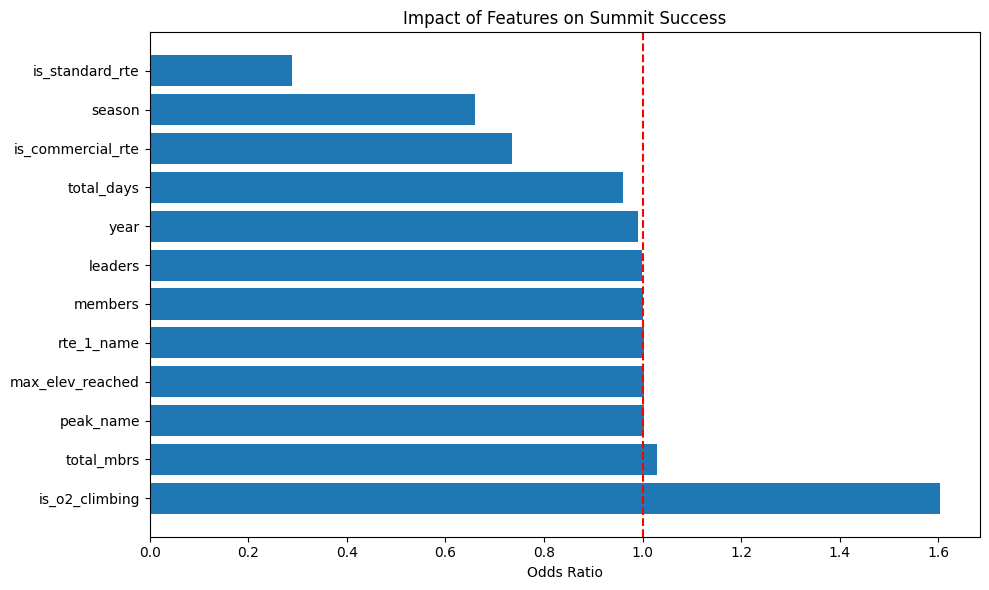

In [6]:
plt.figure(figsize=(10, 6))
plt.barh(coeffs['Feature'], coeffs['Odds Ratio'])
plt.xlabel("Odds Ratio")
plt.title("Impact of Features on Summit Success")
plt.axvline(1, color='red', linestyle='--')
plt.tight_layout()
plt.show()


[0.97326757 0.87078024 0.89998896 0.83519895 0.8601798  0.43028764
 0.44182532 0.98404481 0.55109607 0.4159901 ]


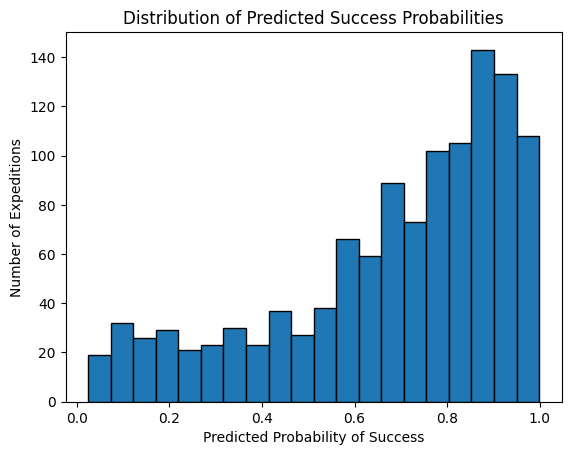

In [7]:
y_probs = model.predict_proba(X_test)[:, 1]

print(y_probs[:10])  # See first 10 probabilities

import matplotlib.pyplot as plt

plt.hist(y_probs, bins=20, edgecolor='black')
plt.xlabel("Predicted Probability of Success")
plt.ylabel("Number of Expeditions")
plt.title("Distribution of Predicted Success Probabilities")
plt.show()


In [20]:
threshold = 0.7
y_pred_custom = (y_probs >= threshold).astype(int)

from sklearn.metrics import classification_report

print(classification_report(y_test, y_pred_custom))


              precision    recall  f1-score   support

           0       0.58      0.70      0.63       420
           1       0.81      0.72      0.76       763

    accuracy                           0.71      1183
   macro avg       0.69      0.71      0.70      1183
weighted avg       0.73      0.71      0.72      1183



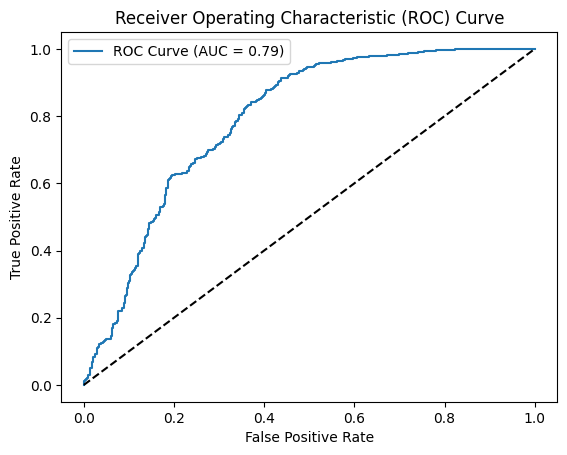

In [18]:
from sklearn.metrics import roc_curve, roc_auc_score

fpr, tpr, thresholds = roc_curve(y_test, y_probs)
auc_score = roc_auc_score(y_test, y_probs)

plt.plot(fpr, tpr, label=f"ROC Curve (AUC = {auc_score:.2f})")
plt.plot([0,1], [0,1], 'k--')  # Diagonal line for random guessing
plt.xlabel("False Positive Rate")
plt.ylabel("True Positive Rate")
plt.title("Receiver Operating Characteristic (ROC) Curve")
plt.legend()
plt.show()


In [11]:
results = X_test.copy()
results['True_Label'] = y_test
results['Predicted_Prob'] = y_probs
results['Predicted_Label'] = model.predict(X_test)
results.to_csv("logistic_regression_results.csv", index=False)


In [12]:
import sys
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import matplotlib
import scipy
import sklearn

print("Python version:", sys.version)
print("pandas version:", pd.__version__)
print("numpy version:", np.__version__)
print("matplotlib version:", matplotlib.__version__)
print("scipy version:", scipy.__version__)
print("sklearn version:", sklearn.__version__)


Python version: 3.9.6 (default, Nov 11 2024, 03:15:38) 
[Clang 16.0.0 (clang-1600.0.26.6)]
pandas version: 2.2.3
numpy version: 2.0.2
matplotlib version: 3.9.4
scipy version: 1.13.1
sklearn version: 1.6.1
